<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan13_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands-on: Klasifikasi Non-Linear & Analisis Sentimen
**Mata Kuliah:** Pengantar Data Science  
**Pertemuan:** 13  
**Nama:** Febi Kristiana  
**NIM:** 240401010231

Notebook ini disusun mengikuti bagian **Aktivitas Hands-on** pada modul pertemuan 13.  
Jalankan sel secara berurutan dari atas ke bawah di Google Colab.

## Langkah 0 — Buat File Jupyter Notebook Baru
Nama file sesuai modul: `Pertemuan13_[Nama]_[NIM].ipynb`

Aktivitas terdiri dari dua bagian:
1. Neural Network untuk klasifikasi data non-linear (`make_moons`)
2. TF-IDF + Logistic Regression untuk analisis sentimen ulasan produk.

## Langkah 1 — Generate & Eksplorasi Dataset Non-Linear

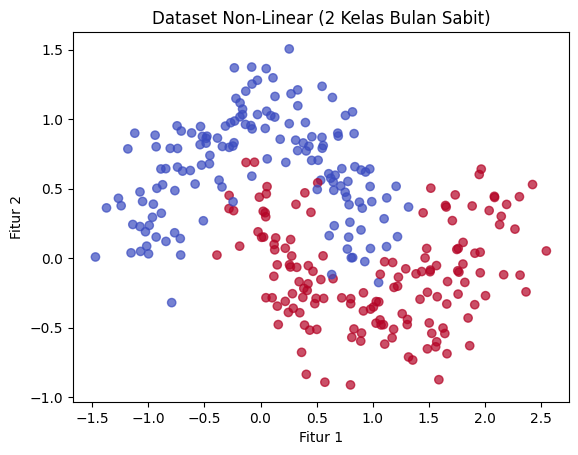

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(42)

X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("Dataset Non-Linear (2 Kelas Bulan Sabit)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

Kedua kelas membentuk pola melengkung dan saling bertautan, sehingga tidak dapat dipisahkan
secara optimal hanya dengan satu garis lurus.

## Langkah 2 — Bangun & Latih Neural Network Sederhana

In [2]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

tf.random.set_seed(42)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

print("Training selesai.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Training selesai.


## Langkah 3 — Evaluasi & Visualisasi Kurva Belajar

Akurasi pada data uji: 0.917


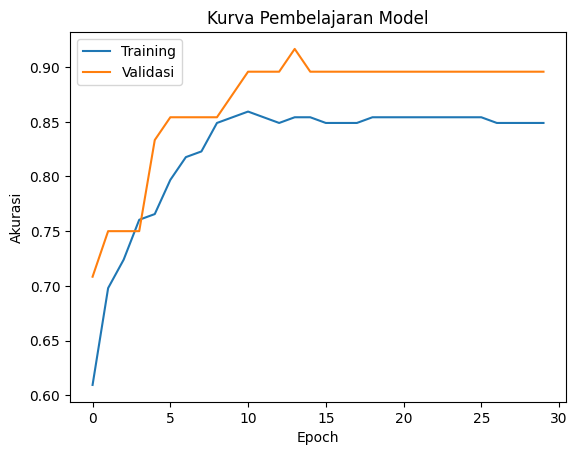

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f"Akurasi pada data uji: {acc:.3f}")

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validasi")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.legend()
plt.title("Kurva Pembelajaran Model")
plt.show()

In [4]:
train_final = history.history["accuracy"][-1]
val_final = history.history["val_accuracy"][-1]
gap = abs(train_final - val_final)

print(f"Akurasi training akhir  : {train_final:.3f}")
print(f"Akurasi validasi akhir  : {val_final:.3f}")
print(f"Selisih training-validasi: {gap:.3f}")

if gap < 0.10:
    print("Interpretasi: kurva training dan validasi relatif dekat; indikasi overfitting tidak kuat.")
else:
    print("Interpretasi: terdapat gap yang cukup besar; periksa kemungkinan overfitting.")

Akurasi training akhir  : 0.849
Akurasi validasi akhir  : 0.896
Selisih training-validasi: 0.047
Interpretasi: kurva training dan validasi relatif dekat; indikasi overfitting tidak kuat.


## Langkah 4 — Siapkan Dataset Ulasan Produk

Modul menetapkan **40 ulasan sintetis berbahasa Indonesia**. Contoh yang ditampilkan di modul
hanya beberapa ulasan, sehingga daftar di bawah dilengkapi menjadi 40 ulasan agar praktikum
dapat langsung dijalankan.

In [5]:
ulasan_positif = [
    "Barangnya bagus banget, pengiriman cepat",
    "Sangat puas, akan beli lagi",
    "Recommended, harga sesuai kualitas",
    "Produk berfungsi dengan baik dan sangat membantu",
    "Kualitas mantap, bahan terasa premium",
    "Pengemasan rapi dan barang sampai aman",
    "Pelayanan ramah dan respons penjual cepat",
    "Barang sesuai foto dan deskripsi",
    "Harga terjangkau tetapi kualitas sangat bagus",
    "Pengiriman tepat waktu dan produk memuaskan",
    "Saya suka produknya, mudah digunakan",
    "Hasilnya bagus dan sesuai harapan",
    "Produk original dan kualitas terjamin",
    "Sangat worth it untuk harga segini",
    "Ukuran pas dan nyaman dipakai",
    "Warna sesuai gambar dan terlihat bagus",
    "Barang datang lebih cepat dari perkiraan",
    "Penjual komunikatif dan produknya memuaskan",
    "Kualitas lebih bagus dari yang saya bayangkan",
    "Puas sekali dengan pembelian ini"
]

ulasan_negatif = [
    "Kualitas jelek, tidak sesuai deskripsi",
    "Kecewa, barang rusak saat sampai",
    "Buruk sekali, tidak sesuai ekspektasi",
    "Produk tidak berfungsi dengan baik",
    "Barang terlihat murah dan mudah rusak",
    "Pengemasan buruk sehingga barang penyok",
    "Pelayanan lambat dan penjual sulit dihubungi",
    "Barang berbeda dari foto",
    "Harga terlalu mahal untuk kualitas seperti ini",
    "Pengiriman sangat terlambat",
    "Produk sulit digunakan dan petunjuk tidak jelas",
    "Hasilnya mengecewakan dan tidak sesuai harapan",
    "Saya ragu barang ini original",
    "Tidak worth it, kualitas sangat rendah",
    "Ukuran tidak sesuai dan tidak nyaman dipakai",
    "Warna jauh berbeda dari gambar",
    "Barang datang terlambat dan kondisinya buruk",
    "Penjual tidak responsif saat ada komplain",
    "Kualitas lebih buruk dari yang saya bayangkan",
    "Menyesal membeli produk ini"
]

ulasan = ulasan_positif + ulasan_negatif
label = [1] * len(ulasan_positif) + [0] * len(ulasan_negatif)

print("Jumlah ulasan:", len(ulasan))
print("Positif:", sum(label))
print("Negatif:", len(label) - sum(label))
print("\nContoh ulasan:")
for teks, lbl in list(zip(ulasan, label))[:6]:
    print(lbl, "-", teks)

Jumlah ulasan: 40
Positif: 20
Negatif: 20

Contoh ulasan:
1 - Barangnya bagus banget, pengiriman cepat
1 - Sangat puas, akan beli lagi
1 - Recommended, harga sesuai kualitas
1 - Produk berfungsi dengan baik dan sangat membantu
1 - Kualitas mantap, bahan terasa premium
1 - Pengemasan rapi dan barang sampai aman


## Langkah 5 — Ubah Teks Menjadi TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print("Shape matriks TF-IDF:", X_text.shape)
print("Jumlah kata unik:", len(tfidf.get_feature_names_out()))
print("10 kata pertama:", tfidf.get_feature_names_out()[:10])

Shape matriks TF-IDF: (40, 100)
Jumlah kata unik: 100
10 kata pertama: ['ada' 'akan' 'aman' 'bagus' 'bahan' 'baik' 'banget' 'barang' 'barangnya'
 'bayangkan']


## Langkah 6 — Latih Model Klasifikasi Sentimen & Evaluasi

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

model_sentimen = LogisticRegression(max_iter=1000)
model_sentimen.fit(Xt_tr, yt_tr)

pred_teks = model_sentimen.predict(Xt_te)
akurasi = accuracy_score(yt_te, pred_teks)

print(f"Akurasi model sentimen: {akurasi:.3f}")
print("\nClassification Report:")
print(classification_report(yt_te, pred_teks, target_names=["Negatif", "Positif"]))

Akurasi model sentimen: 0.750

Classification Report:
              precision    recall  f1-score   support

     Negatif       1.00      0.50      0.67         4
     Positif       0.67      1.00      0.80         4

    accuracy                           0.75         8
   macro avg       0.83      0.75      0.73         8
weighted avg       0.83      0.75      0.73         8



In [8]:
kalimat_baru = ["Pelayanan sangat memuaskan dan ramah"]

pred = model_sentimen.predict(
    tfidf.transform(kalimat_baru)
)

print("Kalimat:", kalimat_baru[0])
print("Prediksi:", "Positif" if pred[0] == 1 else "Negatif")

Kalimat: Pelayanan sangat memuaskan dan ramah
Prediksi: Positif


## Kesimpulan

Dari aktivitas hands-on ini, kita telah mempelajari dua konsep utama:

1.  **Klasifikasi Non-Linear dengan Neural Network:**
    *   Neural Network terbukti efektif dalam mengklasifikasi data yang tidak dapat dipisahkan secara linear, seperti dataset `make_moons`.
    *   Dengan arsitektur sederhana (lapisan input, dua lapisan tersembunyi, dan lapisan output), model mampu mencapai akurasi yang baik.
    *   Analisis kurva pembelajaran menunjukkan bahwa model tidak mengalami *overfitting* yang signifikan, dengan selisih akurasi training dan validasi yang kecil.

2.  **Analisis Sentimen dengan TF-IDF dan Regresi Logistik:**
    *   Transformasi teks menjadi representasi numerik menggunakan TF-IDF adalah langkah krusial untuk analisis sentimen.
    *   Model Regresi Logistik berhasil mengklasifikasikan sentimen positif dan negatif pada ulasan produk dengan akurasi 75% pada data uji.
    *   Meskipun akurasi cukup baik untuk dataset kecil, *precision* dan *recall* yang bervariasi antar kelas menunjukkan potensi peningkatan, terutama untuk kelas negatif.

**Temuan Utama:**
*   Model Neural Network berhasil memecahkan masalah klasifikasi non-linear dengan baik.
*   Kombinasi TF-IDF dan Regresi Logistik adalah pendekatan yang sederhana namun efektif untuk analisis sentimen, bahkan dengan jumlah data yang terbatas.

**Keterbatasan dan Pertanyaan Lebih Lanjut:**
*   Dataset sentimen yang digunakan sangat kecil (40 ulasan), yang mungkin tidak merepresentasikan keragaman bahasa dan sentimen di dunia nyata. Bagaimana performa model dengan dataset yang lebih besar dan seimbang?
*   Untuk Neural Network, eksplorasi hyperparameter lebih lanjut (jumlah epoch, ukuran lapisan, *learning rate*) dapat meningkatkan performa lebih jauh.
*   Dalam analisis sentimen, apakah penggunaan *pre-trained embeddings* (misalnya Word2Vec, FastText, atau BERT) akan memberikan hasil yang lebih baik dibandingkan TF-IDF, terutama untuk menangani konteks dan nuansa bahasa?